# K-뷰티 소비자 강점 신호 발굴 — 온사이트 큐레이션 · CRM 메시지 차별화 파이프라인
### 글로벌 뷰티 플랫폼 '피어나' 데이터 기반 운영·마케팅 직무 지원 — 5단계 요건정의서 실행본 (긍정 강점 · 유튜브+네이버+구글트렌드판)



#### 이 노트북이 하는 일을 한 문장으로
> 글로벌 시장의 소비자가 K-뷰티 상품을 **자발적으로 칭찬·추천하는 핵심 강점**이 무엇인지, 그리고 그 강점이 **어느 채널(영상 댓글 vs 탐색·후기 본문)** 에서 더 강하게 나타나는지를 데이터로 찾아, **온사이트 큐레이션**과 **CRM(이메일·왓츠앱) 메시지**를 어떻게 차별화할지의 근거를 만드는 분석입니다.

#### 이 분석이 '피어나' 직무와 닿는 지점
| 채용 담당업무 | 이 노트북이 제공하는 근거 |
|---|---|
| 유저 취향·소비 선호도 파악 → 온사이트 큐레이션 | **[산출물 1] 강점 토픽 비중** — 소비자가 무엇을 칭찬하는지(추천·선물 동기 / 발색 / 지속력)를 정량화해 큐레이션 우선순위로 전환 |
| 구매 전환율 향상 | **[산출물 3] 강점 × 채널 검정** — 전환을 끌어올리는 추천·선물 동기가 어느 접점에 쏠리는지 → 지면·메시지 배치 근거 |
| 이메일·왓츠앱 CRM 메시지 세팅 | **[산출물 2] 긍정 급증 시계열** — 호감이 갑자기 오른 시점(캠페인·바이럴 후보)을 잡아 CRM 발송 타이밍·소구점 설계 |
| 지표 분석 기반 인사이트 도출 | 모든 결론에 통계 검정(카이제곱·효과크기)·한계 명시 → "감이 아니라 지표로 말하는" 운영 |

#### 전체 흐름 (5단계)
1. **요건 정의**
2. **데이터 수집·거버넌스** — 합법적으로 텍스트를 모읍니다.
3. **모델링** — 모은 글을 (가) 긍정/부정으로 분류하고 (나) 긍정 글에서 '강점 주제'를 자동으로 묶습니다.
4. **검증·보고서화** — 강점이 통계적으로 의미 있는지 검정하고, 그래프로 만듭니다.
5. **MLOps·사후관리**

데이터 수집은 다음 세 가지 공식·합법 소스를 사용

- **유튜브 Data API v3** — K-뷰티 리뷰 영상의 댓글 (구어체·글로벌 소비자 반응, 키 필요)
- **네이버 검색 API** — 블로그·뉴스의 K-뷰티 언급 본문 (탐색·후기 글, 키 필요)
- **구글 트렌드(Google Trends, pytrends)** — K-뷰티 키워드 검색 관심도 시계열 · **시장(geo) 비교 가능** (키 불필요)

> - 이 노트북은 기본적으로 **합성(synthetic) 데이터**를 만들어 파이프라인이 처음부터 끝까지 에러 없이 도는 것을 보여줌
> - 청사진 원안의 **Mecab(형태소) + KcBERT(감성)** 는 '프로덕션(실무) 경로'이며, 여기서는 설치 없이 즉시 도는 '기본 경로'로 대체하고
>   프로덕션 코드는 셀마다 주석으로 표시함
> - **댓글(유튜브) vs 블로그·뉴스(네이버)** 두 채널 비교는, 같은 강점도 소비자 접점마다 다르게 부각된다는 점을 보임 - 즉 **온사이트 지면과 CRM 메시지를 한 가지로 통일하면 안 되는 이유**
>
- 유럽 유저 데이터로 확장할 때는 (a) 구글 트렌드 `TREND_GEO`를 대상 국가코드(예: `"FR"`, `"DE"`, `"GB"`)로 바꾸고, (b) 감성 모델을 다국어/영어 체크포인트로 교체하며, (c) 수집 키워드를 현지어로 바꾸면 동일 골격이 그대로 작동합니다.
- 한국어 경로는 'K-뷰티 본국 레퍼런스'로 두고, 시장별로 같은 파이프라인을 복제하여 이용

### 1. 함수 해설 — 환경 준비용 도우미 함수 3개

| 함수 | 한 줄 역할 |
|---|---|
| `_is_colab()` | 지금 구글 Colab에서 돌고 있는지 확인 |
| `_pip_install(pkg)` | 필요한 파이썬 패키지를 *여러 방법으로* 설치 시도 (한 번 실패해도 다른 방법으로) |
| `_install_mecab()` | 한국어 형태소 분석기 'Mecab'을 설치 시도 (단계별로) |

> 이 셀의 마지막에서 `USE_GPU` 값을 정하고 이는 이 값이 뒤(3단계 감성 분류)에서 **KcBERT(딥러닝) 경로**를 쓸지 **규칙 기반 경로**를 쓸지를 자동으로 가르게 됨

In [2]:
# --- 패키지 설치 (T4 GPU 사용) ---
# pandas, numpy, scikit-learn, scipy, matplotlib, torch 는 Colab GPU 런타임에 기본 포함됩니다.
# 추가로 (1) 감성 분류용 transformers (2) 구글 트렌드용 pytrends 를 설치합니다.
import sys, subprocess

def _is_colab():
    return "google.colab" in sys.modules

def _pip_install(pkg):
    """여러 방식으로 설치 시도 (실패해도 노트북은 계속 진행)."""
    for extra in ([], ["--break-system-packages"]):
        try:
            r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg] + extra,
                               capture_output=True, text=True)
            if r.returncode == 0:
                return True
        except Exception:
            pass
    return False

# (1) transformers (KcBERT 감성 분류용)
try:
    import transformers  # noqa
    print(" transformers 이미 설치됨")
except Exception:
    ok = _pip_install("transformers")
    print(" transformers 설치 완료" if ok else
          " transformers 설치 실패 — 감성 분류는 규칙 기반으로 폴백합니다.")

# (2) pytrends (구글 트렌드)
try:
    import pytrends  # noqa
    print(" pytrends 이미 설치됨")
except Exception:
    ok = _pip_install("pytrends")
    print(" pytrends 설치 완료" if ok else
          " pytrends 설치 실패 — 구글 트렌드만 건너뜁니다(나머지 분석은 정상 동작).")

# (3) KoNLPy + Mecab (토픽 모델 프로덕션 경로 — 한국어 형태소 분석)
#     Colab에서 Mecab 설치는 다소 까다로워, 표준 방법 → 백업 스크립트 순으로 시도합니다.
#     모두 실패하면 토픽 모델 단계에서 정규식 토크나이저로 자동 폴백합니다(노트북은 계속 진행).
def _install_mecab():
    try:
        from konlpy.tag import Mecab
        Mecab()                      # 사전까지 로드되는지 확인
        return True
    except Exception:
        pass
    # konlpy 패키지 설치
    _pip_install("konlpy")
    # mecab-ko + 사전 설치 (Colab/Ubuntu)
    try:
        subprocess.run(
            "bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)",
            shell=True, executable="/bin/bash", check=False,
            capture_output=True, timeout=600)
    except Exception:
        pass
    # python 바인딩 보강 (일부 환경에서 필요)
    _pip_install("mecab-python3")
    try:
        from konlpy.tag import Mecab
        Mecab()
        return True
    except Exception:
        return False

print(" • KoNLPy/Mecab 설치 시도 (토픽 모델 프로덕션 경로)...")
MECAB_OK = _install_mecab()
print(" Mecab 사용 가능 — 토픽 모델 프로덕션 경로 활성화" if MECAB_OK else
      " Mecab 설치 실패 — 토픽 모델은 정규식 토크나이저로 폴백합니다(분석은 정상 동작).")

# --- GPU(T4) 인식 확인 ---
# 이 결과(USE_GPU)에 따라 감성 분류 단계에서 KcBERT(GPU) 또는 규칙 기반을 자동 선택합니다.
USE_GPU = False
try:
    import torch
    USE_GPU = torch.cuda.is_available()
    if USE_GPU:
        print(f" GPU 인식: {torch.cuda.get_device_name(0)}  (CUDA {torch.version.cuda})")
    else:
        print(" GPU가 잡히지 않았습니다 → 감성 분류는 규칙 기반으로 진행")
        print("   (Colab: 런타임 → 런타임 유형 변경 → T4 GPU 선택 후 세션 다시 시작)")
except Exception as e:
    print(" torch 미탑재 → 규칙 기반 감성으로 진행:", e)

# --- 한글 그래프 폰트 설치 (Colab) ---
if _is_colab():
    try:
        subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"],
                       check=False, capture_output=True)
        import matplotlib.font_manager as fm
        for fp in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(fp)
        print(" 한글 폰트 설치·등록 완료 (NanumGothic)")
    except Exception as e:
        print("폰트 설치 생략:", e)
else:
    print(" Colab이 아닌 환경입니다. 한글 폰트는 시스템에 설치된 것을 사용합니다.")


 transformers 이미 설치됨
 pytrends 이미 설치됨
 • KoNLPy/Mecab 설치 시도 (토픽 모델 프로덕션 경로)...
 Mecab 사용 가능 — 토픽 모델 프로덕션 경로 활성화
 GPU 인식: Tesla T4  (CUDA 12.8)
 한글 폰트 설치·등록 완료 (NanumGothic)


### 코드 해설 — 그래프 한글 폰트 잡기

**그래프에서 한글이 깨지지 않게** 폰트를 지정. matplotlib은 기본적으로 한글 폰트를 모르기 때문에, 설치된 나눔폰트를 찾아 등록하고 없으면 경고만 띄웁니다.
 `axes.unicode_minus=False`는 마이너스 부호(−)가 깨지는 것을 막는 설정입니다.

In [3]:
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
import warnings, glob

# 그래프 한글 폰트 지정 — 시스템에 '실제로 설치된' 폰트만 선택해 깨짐·경고를 방지합니다.
# (런타임 재시작 없이도 인식되도록, 설치된 나눔폰트 파일을 직접 등록한 뒤 선택합니다.)
for _fp in glob.glob("/usr/share/fonts/truetype/nanum/*.ttf"):
    try:
        fm.fontManager.addfont(_fp)
    except Exception:
        pass

_installed = {f.name for f in fm.fontManager.ttflist}
_chosen = None
for cand in ["NanumGothic", "NanumBarunGothic", "Noto Sans CJK KR", "Malgun Gothic", "AppleGothic"]:
    if cand in _installed:
        _chosen = cand
        break

if _chosen:
    matplotlib.rcParams["font.family"] = _chosen
    print(f" 그래프 한글 폰트: {_chosen}")
else:
    # 한글 폰트가 없으면 그래프 글자 깨짐 경고가 쏟아지므로, 해당 경고만 숨기고 안내만 출력
    warnings.filterwarnings("ignore", message="Glyph .* missing from font")
    print(" 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")
    print("   → 0단계 설치 셀을 실행했는지 확인하고, Colab이라면 '런타임 → 세션 다시 시작' 후 다시 실행하세요.")

matplotlib.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지


 그래프 한글 폰트: NanumGothic


## 2. 요건 정의 (Requirements)

**분석 질문**
> K-뷰티 상품에 대한 소비자의 긍정적 반응에서 **'핵심 강점·추천(advocacy) 신호'** 가 무엇이고,
> 그 신호가 **소비자 접점(영상 댓글 vs 탐색·후기 본문)** 에 따라 다르게 나타나는가?
> 그래서 **온사이트 큐레이션 우선순위**와 **CRM(이메일·왓츠앱) 메시지 소구점**을 어떻게 나눠야 하는가?

**산출물 3가지**
1. **긍정 강점 토픽 비중 표** — 칭찬이 어떤 주제(추천·선물 동기 / 발색 / 지속력)로 갈리는지 (LDA 3개 토픽) → *온사이트 큐레이션 우선순위의 근거*
2. **시계열 긍정 감성지수 + 급증 탐지** — 추천·호감이 언제 갑자기 늘었는지(캠페인·바이럴 시점) → *CRM 발송 타이밍의 근거*
3. **'추천·선물' 강점 × 채널 연관성 검정** — 그 강점이 특정 접점에 쏠리는지 (카이제곱 + 효과크기) → *지면·메시지 차별화의 근거*

> **왜 '강점'을 보는가:** 부정 페인포인트를 찾는 분석도 가치 있지만, 운영·마케팅 관점에서는
> "이미 잘 먹히는 소구점을 어느 지면·어느 메시지로 더 키울까"라는 강점 기반 제안이 곧바로 **전환율 개선 액션**으로 이어짐.

**핵심 파라미터는 위 1단계 Config 셀에서 한곳에 관리**

### 함수 해설 — `Config` (설정값 한곳 모으기)

`@dataclass`로 만든 `Config`는 **분석에 쓰는 모든 손잡이(설정값)를 한 상자에 모아둔 것**입니다.

| 설정값 | 뜻 | 바꾸면 생기는 일 |
|---|---|---|
| `seed = 2003` | 난수 고정값 | 같은 seed면 **결과가 항상 동일** → 재현성 확보(남이 돌려도 같은 그림) |
| `n_reviews = 6000` | 합성 리뷰 개수 | 실데이터를 넣으면 무시됨(테스트 전용) |
| `n_topics = 3` | 묶어낼 강점 주제 수 | 늘리면 더 잘게 쪼갬, 줄이면 뭉뚱그림 |
| `max_features = 2000` | 토픽 모델이 볼 최대 단어 수 | 너무 작으면 정보 손실, 너무 크면 잡음↑ |
| `spike_k = 2.0` | 급증 판단 민감도(σ 배수) | 작을수록 예민(2~3이 통상) — 통계 해설 셀에서 상술 |
| `rolling_window = 7` | 이동평균 기간(일) | 시계열을 며칠 단위로 부드럽게 볼지 |


In [4]:
from dataclasses import dataclass, field
from typing import List

# ─────────────────────────────────────────────────────────────
#  [1단계] 요건 정의 — 분석에 쓰는 모든 설정값을 한곳에 모읍니다.
#  실제 데이터로 바꿀 때 여기 숫자만 고치면 되므로, 비전문가도 안전하게 조정할 수 있습니다.
# ─────────────────────────────────────────────────────────────
@dataclass
class Config:
    seed: int = 2003               # 난수 고정값. 같은 seed면 결과가 항상 동일 → '재현성' 확보
    n_reviews: int = 6000          # 합성 리뷰 개수 (실데이터로 교체하면 무시됨)
    n_topics: int = 3              # 긍정 글에서 묶어낼 '강점 주제'의 개수 (3개)
    max_features: int = 2000       # 토픽 모델이 살펴볼 최대 단어 수
    spike_k: float = 2.0           # '급증'으로 볼 민감도. 평균에서 표준편차의 몇 배 이상 벗어나면 급증으로 판단 (2~3 사이가 통상)
    rolling_window: int = 7        # 시계열을 부드럽게 볼 때 쓰는 이동평균 기간(일)
    # 발견 채널: youtube(영상 댓글) / naver(블로그·뉴스 본문) — 수집 출처 기반
    channels: List[str] = field(default_factory=lambda: ["youtube", "naver"])
    data_path: str = None          # 실데이터 CSV 경로 (None이면 합성 데이터 생성)

CFG = Config()

import numpy as np, random
np.random.seed(CFG.seed)
random.seed(CFG.seed)

print("설정 완료:", CFG)


설정 완료: Config(seed=2003, n_reviews=6000, n_topics=3, max_features=2000, spike_k=2.0, rolling_window=7, channels=['youtube', 'naver'], data_path=None)


## 3. 데이터 수집 · 거버넌스 (Data & Governance)

**출처 원칙:** 공식 API만 사용. 비공식 크롤링(약관이 금지하는 자동 수집)은 코드로 제공하지 않음.

**거버넌스(데이터 관리 원칙):** 작성자를 식별할 수 있는 정보(PII)는 제거하고, 모아서 익명화한 결과만 사용 (개인정보보호법의 최소수집·목적제한 원칙. 유럽 유저 데이터로 확장 시에는 **GDPR**의 적법 처리근거·최소수집·목적제한을 동일하게 적용).

이 단계는 **세 가지 공식·합법 소스**로 K-뷰티 관련 긍정 신호를 수집합니다.

| 소스 | 방식 | 수집 대상 |
|---|---|---|
| 유튜브 | Data API v3 | K-뷰티 리뷰 영상의 **댓글** (짧고 구어체인 반응, 글로벌) |
| 네이버 | 검색 API | 블로그·뉴스의 K-뷰티 언급 **본문**(제목+요약) (탐색·후기 글) |
| 구글 트렌드 | pytrends | K-뷰티 키워드 **검색 관심도 시계열** · **시장(geo)별 비교** |

**사용법:** 아래 셀의 `YOUTUBE_API_KEY` / `NAVER_CLIENT_ID` / `NAVER_CLIENT_SECRET` 에 **본인 키만 꽂으면** 실제 수집이 동작.
구글 트렌드는 키 없이 자동 동작하며, 텍스트 수집 키가 모두 비어 있으면 **합성 데이터(테스트용)** 로 자동 폴백.


### 함수 해설 — 데이터 수집·정제 함수 묶음

**(A) 텍스트 청소·정규화 — 분석 전 '재료 손질'**

| 함수 | 하는 일 | 왜 필요한가 |
|---|---|---|
| `clean_text(t)` | HTML 태그·이메일·전화번호·@아이디 제거 | 광고 태그·**개인정보(PII)** 를 분석 전에 제거(개인정보보호법 최소수집) |
| `to_naive_date(value)` | 어떤 날짜 형식이든 '시간대 없는 날짜'로 통일 | 유튜브(시간대 있음)와 네이버(없음)를 한 표에 섞을 때 나는 오류를 **원천 차단** |
| `infer_rating(text)` | 평점이 없는 글의 점수를 긍·부정 단어 수로 1~5점 추정 | 댓글엔 별점이 없으므로, 감성의 *대용 신호*를 만들어 둠(실데이터에 평점 있으면 그걸 우선) |

**(B) 공식 API 수집

| 함수 | 출처 | 수집물 |
|---|---|---|
| `_yt_get(path, params)` | 유튜브 API 호출 *공통 도우미* | (내부용) URL 만들고 응답을 JSON으로 |
| `collect_youtube(...)` | 유튜브 Data API v3 | 리뷰 영상의 **댓글**(구어체 반응) |
| `collect_naver(...)` | 네이버 검색 API | 블로그·뉴스의 **본문**(정보성 후기) |
| `collect_google_trends(...)` | 구글 트렌드(pytrends) | **검색 관심도 시계열**(텍스트 아님 → 별도 보관) |

**(C) 합성 데이터 — 키가 없을 때의 '연습용 재료'**

`make_synthetic_reviews(cfg)`는 API 키가 없을 때 **가짜 리뷰를 만들어** 파이프라인이 끝까지 도는지 보여줍니다.

In [5]:
import os
import pandas as pd
import numpy as np
import time, re, datetime, urllib.parse, urllib.request, urllib.error, json
from dataclasses import dataclass

# =====================================================================
#   API 키 주입
#  ------------------------------------------------------------------

#    1) Colab Secrets  (좌측 아이콘 → 이름: YOUTUBE_API_KEY 등으로 등록)
#    2) 환경변수 os.environ
#    3) 둘 다 없으면 "" (빈 값) → 자동으로 합성 데이터 데모로 폴백
#  ⇒ 키가 하나도 없어도 이 노트북은 위→아래 실행만으로 끝까지 돕니다.
# =====================================================================
def _load_key(name: str, default: str = "") -> str:
    # (1) Colab Secrets 우선
    try:
        from google.colab import userdata
        v = userdata.get(name)
        if v:
            return str(v).strip()
    except Exception:
        pass
    # (2) 환경변수 → (3) 기본값
    return os.environ.get(name, default).strip()

YOUTUBE_API_KEY     = _load_key("YOUTUBE_API_KEY")
NAVER_CLIENT_ID     = _load_key("NAVER_CLIENT_ID")
NAVER_CLIENT_SECRET = _load_key("NAVER_CLIENT_SECRET")

# =====================================================================
#  실행 설정 (CFG) — 합성 데이터·채널 등 동작 파라미터
#  원본 코드가 make_synthetic_reviews(CFG) 를 호출하지만 CFG 정의가
#  빠져 있어 키 없는 상태에서 NameError 로 멈췄습니다. 여기서 정의합니다.
# =====================================================================
@dataclass
class Config:
    seed: int = 42                              # 재현성 고정 시드
    n_reviews: int = 600                        # 합성 리뷰 생성 개수(데모용)
    channels: tuple = ("youtube", "naver")      # 수집 채널(합성 시 확률 배분 대상)

CFG = Config()

# 수집 파라미터 (실데이터로 바꿀 때 이 부분만 조정하면 됩니다)
# 분석 대상 K-뷰티 상품/브랜드 키워드 — 큐레이션 후보에 맞춰 교체하세요.
YT_VIDEO_QUERY      = "K-beauty lip product review"   # 글로벌 리뷰 영상 위주(현지어로 교체 가능)
YT_MAX_VIDEOS       = 5
YT_COMMENTS_PER_VID = 100
NAVER_QUERIES       = ["K뷰티 립 틴트 추천", "K뷰티 쿠션 후기", "K뷰티 아이 팔레트 추천"]
NAVER_DISPLAY       = 100                         # 검색어당 최대 100건 (네이버 API 1회 한도)
# 구글 트렌드 키워드 — 시장 비교 시 영어/현지어 키워드 권장
TREND_KEYWORDS      = ["K beauty", "Korean skincare"]
TREND_TIMEFRAME     = "today 3-m"                 # 최근 3개월
TREND_GEO           = ""                          # "" = 전세계, "KR"=한국, "FR"/"DE"/"GB"=유럽 시장별 비교

# ---------------------------------------------------------------------
#  텍스트 정제 유틸: HTML 태그·식별정보 제거 (거버넌스)
#  왜? 수집한 글에는 광고 태그, 작성자 아이디·연락처가 섞일 수 있어
#      개인정보 보호 차원에서 분석 전에 먼저 지웁니다.
# ---------------------------------------------------------------------
_TAG = re.compile(r"<[^>]+>")
_PII_HANDLE = re.compile(r"@[\w가-힣._-]+")            # @아이디 제거
_PII_PHONE  = re.compile(r"01[016789][-\s]?\d{3,4}[-\s]?\d{4}")
_PII_EMAIL  = re.compile(r"[\w.+-]+@[\w-]+\.[\w.-]+")

def clean_text(t: str) -> str:
    t = _TAG.sub(" ", str(t))
    t = t.replace("&quot;", '"').replace("&amp;", "&").replace("&lt;", "<").replace("&gt;", ">")
    t = _PII_EMAIL.sub(" ", t); t = _PII_PHONE.sub(" ", t); t = _PII_HANDLE.sub(" ", t)
    return re.sub(r"\s+", " ", t).strip()

# 긍정/부정 사전 — 평점이 없는 글의 감성을 약식 추정하기 위한 보조 단어 목록
POS_WORDS = ["좋아","예뻐","예쁘","만족","추천","촉촉","최고","잘 어울","예쁨","발색","지속력",
             "데일리","선물","고급","부드럽","가성비","재구매","인생","화사"]
NEG_WORDS = ["안 맞","별로","아쉽","실패","끈적","무거","지워","이염","달라","밀려"]

def to_naive_date(value):
    """어떤 형태의 날짜든 '시간대 정보 없는(tz-naive) 날짜'로 통일한다.
    유튜브(tz-aware, ...Z)와 네이버(tz-naive)를 한 컬럼에 섞을 때 발생하는
    'Cannot mix tz-aware with tz-naive values' 오류를 원천 차단한다."""
    ts = pd.to_datetime(value, errors="coerce", utc=True)  # 일단 UTC 기준 tz-aware 로 파싱
    if pd.isna(ts):
        return pd.Timestamp.today().normalize()
    return ts.tz_localize(None).normalize()                # tz 정보 제거 + 날짜만 남김

def infer_rating(text: str) -> int:
    # 긍정 단어 수에서 부정 단어 수를 빼서 1~5점으로 환산 (실데이터에 평점이 있으면 그걸 우선 사용)
    s = sum(w in text for w in POS_WORDS) - sum(w in text for w in NEG_WORDS)
    return 5 if s >= 2 else 4 if s == 1 else 3 if s == 0 else 2 if s == -1 else 1

# ---------------------------------------------------------------------
#  (A) 유튜브 Data API v3 — 리뷰 영상 댓글  (channel = "youtube")
# ---------------------------------------------------------------------
def _yt_get(path, params):
    params = {**params, "key": YOUTUBE_API_KEY}
    url = f"https://www.googleapis.com/youtube/v3/{path}?" + urllib.parse.urlencode(params)
    with urllib.request.urlopen(url, timeout=10) as resp:
        return json.loads(resp.read().decode("utf-8"))

def collect_youtube(query, max_videos=5, per_video=100):
    rows = []
    try:
        search = _yt_get("search", {"part": "snippet", "q": query, "type": "video",
                                    "maxResults": max_videos, "relevanceLanguage": "ko"})
    except urllib.error.HTTPError as e:
        print(f"   유튜브 검색 HTTP {e.code}: {e.reason} — 키·쿼터 확인")
        return rows
    except Exception as e:
        print(f"   유튜브 검색 실패: {e}")
        return rows
    for v in search.get("items", []):
        vid = v.get("id", {}).get("videoId")
        if not vid:
            continue
        try:
            ct = _yt_get("commentThreads", {"part": "snippet", "videoId": vid,
                                            "maxResults": min(100, per_video),
                                            "textFormat": "plainText", "order": "relevance"})
        except Exception as e:
            print(f"  댓글 수집 실패(video {vid}): {e}")
            continue
        for item in ct.get("items", []):
            sn = item["snippet"]["topLevelComment"]["snippet"]
            text = clean_text(sn.get("textDisplay", ""))
            if len(text) < 10:
                continue
            rows.append({"text": text, "rating": infer_rating(text), "channel": "youtube",
                         "date": to_naive_date(sn.get("publishedAt")),
                         "source": "youtube"})
        time.sleep(0.1)
    return rows

# ---------------------------------------------------------------------
#  (B) 네이버 검색 API — 블로그·뉴스 본문  (channel = "naver")
#      X-Naver-Client-Id / Secret 헤더 인증. blog·news 두 엔드포인트 사용.
# ---------------------------------------------------------------------
def collect_naver(queries, display=100):
    rows = []
    auth_failed = False  # 401 발생 시 반복 호출 중단
    for q in queries:
        if auth_failed:
            break
        for endpoint in ("blog", "news"):
            url = (f"https://openapi.naver.com/v1/search/{endpoint}.json"
                   f"?query={urllib.parse.quote(q)}&display={min(100, display)}&sort=sim")
            req = urllib.request.Request(url, headers={
                "X-Naver-Client-Id": NAVER_CLIENT_ID,
                "X-Naver-Client-Secret": NAVER_CLIENT_SECRET})
            try:
                with urllib.request.urlopen(req, timeout=10) as resp:
                    items = json.loads(resp.read().decode("utf-8")).get("items", [])
            except urllib.error.HTTPError as e:
                if e.code == 401:
                    print("  ❌ 네이버 401 Unauthorized — 인증 실패.")
                    print("     1) developers.naver.com 앱의 'API 설정'에 '검색'이 추가됐는지")
                    print("     2) Client ID·Secret 오타·공백 없는지, 둘이 바뀌지 않았는지 확인")
                    auth_failed = True
                    break
                print(f"  네이버 {endpoint} '{q}' HTTP {e.code}: {e.reason}")
                continue
            except Exception as e:
                print(f"  네이버 {endpoint} '{q}' 호출 실패: {e}")
                continue
            for it in items:
                text = clean_text(it.get("title", "") + " " + it.get("description", ""))
                if len(text) < 10:
                    continue
                raw = it.get("postdate") or it.get("pubDate") or ""
                # 블로그(postdate=YYYYMMDD)·뉴스(RFC822) 모두 동일 헬퍼로 tz-naive 통일
                date = (to_naive_date(pd.to_datetime(raw, format="%Y%m%d"))
                        if str(raw).isdigit() else to_naive_date(raw))
                rows.append({"text": text, "rating": infer_rating(text), "channel": "naver",
                             "date": date, "source": f"naver_{endpoint}"})
            time.sleep(0.1)  # 쿼터 매너
    return rows

# ---------------------------------------------------------------------
#  (C) 구글 트렌드 (pytrends) — 검색 관심도 시계열 (키 불필요)
#    텍스트가 아니라 '관심도 지수'--> 감성 분석과 섞지 않고 별도 trend_df 로 반환
# ---------------------------------------------------------------------
def collect_google_trends(keywords, timeframe="today 3-m", geo=""):
    try:
        from pytrends.request import TrendReq
        py = TrendReq(hl="ko", tz=540)
        py.build_payload(keywords, timeframe=timeframe, geo=geo)
        df = py.interest_over_time()
        if "isPartial" in df.columns:
            df = df.drop(columns=["isPartial"])
        print(f" 구글 트렌드 수집: {len(df)}개 시점, 키워드 {keywords}")
        return df
    except Exception as e:
        print(f"  구글 트렌드 수집 실패(네트워크/쿼터/미설치 가능): {e}")
        return pd.DataFrame()

# ---------------------------------------------------------------------
#  합성 데이터 폴백 (키 미입력 시) — 긍정 강점 신호를 채널별로 심음
#    합성=탐색·시연용. 실제 PT 수치로 사용 금지.
#    설계: youtube 댓글에는 '선물 만족·추천' 강점이, naver 블로그·뉴스에는 '발색/지속력' 강점이 더 많이 나타나도록 구성
#         (→ 검정 단계에서 채널 간 차이가 보이도록 의도적으로 심은 것임을 자가감사에 명시)
# ---------------------------------------------------------------------
def make_synthetic_reviews(cfg):
    rng = np.random.default_rng(cfg.seed)
    pos_gift  = ["선물로 받았는데 색이 잘 어울려서 만족스럽고 추천해요",
                 "친구 선물했더니 발색 예쁘다고 추천 고마워했어요",
                 "선물용 패키지가 고급스러워서 선물 만족도 최고 추천",
                 "기념일 선물로 추천 받아서 샀는데 받는 사람도 만족",
                 "선물 추천템으로 딱 만족스럽고 또 선물하고 싶어요"]
    pos_color = ["발색 진짜 예쁘고 색상이 화사해서 데일리로 만족해요",
                 "색감 발색 예쁨 화사한 컬러라 자주 손이 가요",
                 "발색 선명하고 색상 예뻐서 인생 립이라 추천",
                 "화사한 발색에 색상도 예쁘고 만족스러워요"]
    pos_last  = ["지속력 좋아서 오래 가고 촉촉하게 유지돼서 만족",
                 "지속력 최고라 하루 종일 가고 촉촉해서 추천",
                 "발림 부드럽고 지속력 좋아서 데일리로 만족",
                 "촉촉하고 지속력 길어서 가성비 최고 추천"]
    neg = ["색이 화면이랑 달라서 좀 아쉬워요", "제형이 무거워서 별로였어요", "지속력이 약해서 아쉽네요"]
    rows=[]; start=pd.Timestamp("2025-09-01")
    for i in range(cfg.n_reviews):
        ch = rng.choice(cfg.channels, p=[0.55, 0.45])  # youtube / naver
        is_pos = rng.random() < 0.78
        if is_pos:
            if ch == "youtube":   # 댓글: 선물 만족·추천 강점↑
                p=[0.60,0.22,0.18]
            else:                  # naver: 발색·지속력(정보성 후기) 강점↑
                p=[0.18,0.45,0.37]
            tp=rng.choice(["gift","color","last"], p=p)
            pool={"gift":pos_gift,"color":pos_color,"last":pos_last}[tp]
            text=str(rng.choice(pool)); rating=int(rng.choice([4,5],p=[0.30,0.70]))
        else:
            text=str(rng.choice(neg)); rating=int(rng.choice([2,3],p=[0.5,0.5]))
        rows.append({"text":text,"rating":rating,"channel":ch,
                     "date":start+pd.Timedelta(days=int(rng.integers(0,90))),"source":"synthetic"})
    df=pd.DataFrame(rows)
    sm=(df["date"]>="2025-10-20")&(df["date"]<="2025-10-24")
    if sm.any():
        ex=df[sm&(df["rating"]>=5)]
        if len(ex): df=pd.concat([df,ex.sample(frac=2.0,replace=True,random_state=cfg.seed)],ignore_index=True)
    return df.sample(frac=1.0,random_state=cfg.seed).reset_index(drop=True)

# =====================================================================
#  수집 실행
# =====================================================================
use_text_api = bool(YOUTUBE_API_KEY) or bool(NAVER_CLIENT_ID and NAVER_CLIENT_SECRET)

if use_text_api:
    print(" 공식 API 수집 시작 (유튜브 + 네이버)...")
    collected = []
    if YOUTUBE_API_KEY:
        print(" • 유튜브 Data API...")
        collected += collect_youtube(YT_VIDEO_QUERY, YT_MAX_VIDEOS, YT_COMMENTS_PER_VID)
    else:
        print(" • 유튜브 키 미입력 → 건너뜀")
    if NAVER_CLIENT_ID and NAVER_CLIENT_SECRET:
        print(" • 네이버 검색 API...")
        collected += collect_naver(NAVER_QUERIES, NAVER_DISPLAY)
    else:
        print(" • 네이버 키 미입력 → 건너뜀")

    if collected:
        reviews = pd.DataFrame(collected).drop_duplicates(subset="text").reset_index(drop=True)
        reviews.insert(0, "review_id", [f"R{i:06d}" for i in range(len(reviews))])
        # 혹시라도 tz-aware 값이 남아 있어도 안전하게 tz-naive 로 통일
        reviews["date"] = pd.to_datetime(reviews["date"], errors="coerce", utc=True).dt.tz_localize(None)
        print(f" 텍스트 수집 완료: {len(reviews):,}건")
    else:
        print(" API 응답 0건 → 합성 데이터로 폴백 (예시 수치 — 실측 아님)")
        reviews = make_synthetic_reviews(CFG)
        reviews.insert(0,"review_id",[f"R{i:06d}" for i in range(len(reviews))])
else:
    print(" 텍스트 API 키 미입력 → 합성 데이터 생성 (첫 테스트용 — 예시 수치, 실측 아님 / 실제 PT 수치로 사용 금지)")
    reviews = make_synthetic_reviews(CFG)
    reviews.insert(0, "review_id", [f"R{i:06d}" for i in range(len(reviews))])

# 구글 트렌드는 키가 필요 없으므로 항상 시도 (네트워크/미설치면 빈 DF)
print(" • 구글 트렌드(pytrends)...")
trend_df = collect_google_trends(TREND_KEYWORDS, TREND_TIMEFRAME, TREND_GEO)

print(reviews.head())
print(f"\n총 {len(reviews):,}행 / 채널 분포:\n{reviews['channel'].value_counts()}")


 텍스트 API 키 미입력 → 합성 데이터 생성 (첫 테스트용 — 예시 수치, 실측 아님 / 실제 PT 수치로 사용 금지)
 • 구글 트렌드(pytrends)...
 구글 트렌드 수집: 93개 시점, 키워드 ['K beauty', 'Korean skincare']
  review_id                          text  rating  channel       date  \
0   R000000  기념일 선물로 추천 받아서 샀는데 받는 사람도 만족       5  youtube 2025-10-20   
1   R000001        화사한 발색에 색상도 예쁘고 만족스러워요       5    naver 2025-09-18   
2   R000002  발색 진짜 예쁘고 색상이 화사해서 데일리로 만족해요       5    naver 2025-09-20   
3   R000003                 지속력이 약해서 아쉽네요       2    naver 2025-09-04   
4   R000004            색이 화면이랑 달라서 좀 아쉬워요       3    naver 2025-09-23   

      source  
0  synthetic  
1  synthetic  
2  synthetic  
3  synthetic  
4  synthetic  

총 648행 / 채널 분포:
channel
youtube    344
naver      304
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


### 코드 해설 — 거버넌스 가드(`assert`)와 기초 점검

이 셀은 함수는 아니지만 **거버넌스(데이터 관리) 안전장치**라 중요합니다.

- `assert not found_pii` : 데이터에 이름·전화·이메일 같은 **개인 식별 컬럼이 남아 있으면 즉시 멈춤**. "익명화를 깜빡했는데 그냥 진행"되는 사고를 코드로 차단합니다(개인정보보호법 최소수집·목적제한 원칙의 코드화).
- 표본 크기(N)·기간·채널 분포 출력 : 분석에 들어가기 전 *"재료가 충분하고 골고루 있는가"* 를 눈으로 확인하는 단계입니다.

> `assert`는 "이 조건이 참이 아니면 더 진행하지 마라"는 **자동 안전핀**입니다. 보고서 신뢰도의 출발점은 "위험한 데이터가 안 섞였다"를 스스로 증명하는 것입니다.

In [6]:
# --- 거버넌스 가드: PII 컬럼이 없는지 확인 (개인정보보호법 최소수집) ---
PII_COLS = {"user_id", "nickname", "phone", "email", "name", "address"}
found_pii = PII_COLS & set(reviews.columns)
assert not found_pii, f"❌ PII 컬럼 발견: {found_pii} — 익명화 재확인 필요"

# --- 기본 점검: 표본 크기 · 기간 · 채널 분포 ---
print(f" PII 가드 통과")
print(f"표본 크기 N = {len(reviews):,}건")
print(f"기간 {reviews['date'].min().date()} ~ {reviews['date'].max().date()}")
print("\n발견 채널 분포:")
print(reviews["channel"].value_counts())

# --- 수집 출처 분포 (공식 API 수집 시 추적용) ---
if "source" in reviews.columns:
    print("\n수집 출처:")
    print(reviews["source"].value_counts())

 PII 가드 통과
표본 크기 N = 648건
기간 2025-09-01 ~ 2025-11-29

발견 채널 분포:
channel
youtube    344
naver      304
Name: count, dtype: int64

수집 출처:
source
synthetic    648
Name: count, dtype: int64


## 4. 모델링 — 감성 분류 + 긍정 토픽 군집 (Modeling)

#### 이 단계를 쉽게 말하면
모은 글을 두 번 거릅니다. **(1)** 먼저 칭찬글(긍정)인지 불만글(부정)인지 나누고, **(2)** 칭찬글만 모아
"무엇을 칭찬하는지"를 주제별로 자동으로 묶습니다.

**(1) 감성 분류 — 글을 긍정/부정/중립으로 나누기**
- **GPU 경로(T4):** KcBERT 딥러닝 모델 — 반어·신조어·문맥까지 반영. 0단계에서 GPU가 잡히면 **자동 사용**
-  **폴백 경로:** GPU·모델 로딩 실패 시 평점 + 한국어 긍정/부정 단어 사전으로 자동 전환(에러 없이 계속 진행)

**(2) 토픽 모델 — 칭찬글에서 '강점 주제' 3개 묶기 (LDA)**
-  **프로덕션 경로(기본):** Mecab 형태소 분석 + LDA — 어근·명사 중심으로 군집을 선명하게. 0단계에서 Mecab이 설치되면 **자동 사용**
-  **폴백 경로:** Mecab 설치 실패 시 정규식 토크나이저로 자동 전환(에러 없이 계속 진행)

>  **KcBERT** : 네이버 댓글·구어체 한국어로 사전학습된 BERT 모델이라,
> "안 예쁠 줄 알았는데 예뻐요" 같은 반전·구어 표현을 사전 방식보다 정확히 분류합니다. T4 GPU로 빠르게 추론합니다.
>
>  **LDA**  --> 글마다 어떤 단어가 자주 함께 나오는가"를 보고 비슷한 단어 뭉치를
> 같은 '주제(토픽)'로 자동으로 묶어주는 비지도 학습 기법


### 함수 해설 — 감성 분류 함수 (글을 긍정/부정/중립으로 나누기)

모은 글을 **칭찬글(positive) / 불만글(negative) / 중립(neutral)** 으로 가르는 것

| 함수 | 경로 | 작동 방식 | 장단점 |
|---|---|---|---|
| `rule_sentiment(text, rating)` |  폴백(규칙) | 별점 + 긍·부정 단어 사전으로 판정 | 빠르고 설치 불필요 / 반어·문맥엔 약함 |
| `classify_rule_based()` |  폴백(규칙) | 위 함수를 전체 리뷰에 적용 | — |
| `classify_kcbert_gpu()` |  GPU(딥러닝) | KcBERT 계열 모델로 문맥까지 반영해 추론, 실패 시 `None` 반환 | 정확(반어·신조어 포착) / GPU·모델 로딩 필요 |

**자가감사 연계 — 정직성 장치:** 실제로 어떤 경로가 쓰였는지는 `sentiment_method` 변수(`kcbert_gpu` 또는 `rule`)에 기록되고 출력됩니다. "딥러닝 썼다는데 사실은 규칙 기반이었다" 같은 **능력 과장**을 막기 위한 장치.

> **임계값 해석 — 확률을 라벨로 바꾸는 컷오프:** GPU 경로는 모델이 준 긍정 확률을 이렇게 자릅니다.
>
> | 긍정 확률 | 라벨 | 의미 |
> |---|---|---|
> | ≥ 0.6 | positive | 긍정 신호 충분 |
> | ≤ 0.4 | negative | 부정 신호 충분 |
> | 0.4 ~ 0.6 | neutral | **애매** |
>
> 가운데 회색지대(0.4~0.6)를 중립으로 비워두는 것은 "확신 없는 건 우기지 않는다" 는 보수적 설계

In [8]:
import re

# ---------------------------------------------------------------
# (1) 감성 분류 — T4 GPU가 있으면 KcBERT 계열 모델, 없으면 규칙 기반으로 자동 폴백
# ---------------------------------------------------------------

# 규칙 기반(폴백) 사전 — GPU/모델이 없을 때 사용
POS_LEXICON = ["좋아", "예뻐", "예쁘", "예쁨", "만족", "추천", "촉촉", "최고", "잘 어울",
               "발색", "지속력", "데일리", "선물", "고급", "부드럽", "가성비", "재구매", "인생", "화사"]
NEG_LEXICON = ["안 맞", "별로", "아쉽", "아쉬", "실패", "끈적", "무거", "지워", "이염", "달라", "밀려"]

def rule_sentiment(text: str, rating: int) -> str:
    pos_hit = any(w in text for w in POS_LEXICON)
    neg_hit = any(w in text for w in NEG_LEXICON)
    if rating >= 4 or (rating == 3 and pos_hit and not neg_hit):
        return "positive"
    if rating <= 2 or (rating == 3 and neg_hit):
        return "negative"
    return "positive" if pos_hit else "neutral"

def classify_rule_based():
    return [rule_sentiment(t, r) for t, r in zip(reviews["text"], reviews["rating"])]

# ---- GPU 경로: KcBERT 계열 한국어 감성 모델 (분류 헤드 포함 체크포인트 사용) ----
# 주의: 'beomi/kcbert-base'는 분류 헤드가 없는 '기반 모델'이라 그대로 쓰면 감성 라벨이 무의미합니다.
#       따라서 감성 분류용으로 '파인튜닝된' 한국어 모델을 사용합니다.
SENTIMENT_MODEL = "matthewburke/korean_sentiment"  # KcBERT 계열, 긍/부정 헤드 포함(0=neg,1=pos)
sentiment_method = "rule"  # 실제 사용된 방식 기록용

def classify_kcbert_gpu():
    """T4 GPU에서 KcBERT 계열 모델로 배치 추론. 실패 시 None 반환 → 규칙 기반 폴백."""
    try:
        import torch
        from transformers import AutoTokenizer, AutoModelForSequenceClassification
    except Exception as e:
        print(" transformers/torch 미탑재 → 규칙 기반 사용:", e)
        return None
    if not torch.cuda.is_available():
        print(" GPU 미인식 → 규칙 기반 사용 (런타임 유형을 T4 GPU로 변경하세요)")
        return None
    try:
        device = torch.device("cuda")
        tok = AutoTokenizer.from_pretrained(SENTIMENT_MODEL)
        model = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL).to(device).eval()

        texts = reviews["text"].astype(str).tolist()
        preds = []
        B = 64  # 배치 크기 (T4 메모리에 맞춰 조정 가능)
        for i in range(0, len(texts), B):
            batch = texts[i:i+B]
            enc = tok(batch, return_tensors="pt", truncation=True,
                      padding=True, max_length=128).to(device)
            with torch.no_grad():
                logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1)
            pos_p = probs[:, 1]                      # index 1 = positive
            for p in pos_p.tolist():
                preds.append("positive" if p >= 0.6 else "negative" if p <= 0.4 else "neutral")
        print(f" KcBERT(GPU) 감성 분류 완료: {len(preds):,}건 (모델: {SENTIMENT_MODEL})")
        return preds
    except Exception as e:
        print(" KcBERT 추론 실패 → 규칙 기반으로 폴백:", e)
        return None

# ---- 실행: GPU 경로 우선, 실패하면 규칙 기반 ----
_labels = classify_kcbert_gpu()
if _labels is not None:
    reviews["sentiment"] = _labels
    sentiment_method = "kcbert_gpu"
else:
    reviews["sentiment"] = classify_rule_based()
    sentiment_method = "rule"
    print("규칙 기반(사전) 감성 분류 사용")

print("\n감성 분포:")
print(reviews["sentiment"].value_counts())



 transformers/torch 미탑재 → 규칙 기반 사용: Could not import module 'AutoTokenizer'. Are this object's requirements defined correctly?
규칙 기반(사전) 감성 분류 사용

감성 분포:
sentiment
positive    506
negative    142
Name: count, dtype: int64


###  함수 해설 — 토크나이저 + LDA 토픽 모델 (칭찬 이유를 자동으로 묶기)

**(1) 토크나이저 — 문장을 '의미 단어'로 쪼개기**

| 함수 | 경로 | 방식 |
|---|---|---|
| `_build_mecab_tokenizer()` → `mecab_tokenize()` | 프로덕션 | Mecab 형태소 분석으로 **명사·동사·어근만** 추출 |
| `regex_tokenize(text)` | 폴백 | 한글 2글자 이상을 정규식으로 단순 추출 |

**왜 Mecab(형태소)을 선호하나:** 정규식은 `"예쁘고"`·`"예뻐서"`를 *서로 다른 단어*로 봅니다. Mecab은 어근 `"예쁘"`로 묶고 조사·어미(`은/는/이/가/요`)를 떼어내므로 **같은 뜻이 하나로 모여 토픽이 선명**해집니다. (어느 쪽이 쓰였는지는 `tokenizer_method`에 기록 → 자가감사)

**(2) `CountVectorizer` → `LDA` — 단어 묶음에서 주제 뽑기**

- `CountVectorizer` : 글을 **'단어 빈도표'(문서-단어 행렬)** 로 바꿔 LDA가 읽을 수 있게 만듭니다.
- `LatentDirichletAllocation(LDA)` : *"어떤 단어들이 자주 함께 등장하는가"* 를 보고 비슷한 단어 뭉치를 같은 **주제(토픽)** 로 자동 묶는 **비지도 학습**입니다. 정답 라벨 없이 패턴만으로 묶습니다.

>  **비지도 학습이란:** 글 더미만 보고 알아서 주제를 발견하는 방식입니다. 그래서 어떤 주제가 나올지 미리 정하지 않고 데이터가 말하게 둘 수 있음

>  **`n_topics = 3`은 어떻게 정하나(실무 팁):** 토픽 수는 정답이 없어, 실무에선 여러 값을 시도해 **토픽 일관성(Coherence) 점수가 높고 사람이 해석 가능한 수**를 고름

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Temporary fix for missing CFG attributes due to redefinition in previous cell
# This should ideally be resolved by consolidating Config definitions in the notebook.
if not hasattr(CFG, 'max_features'):
    CFG.max_features = 2000 # Default value from the original Config definition
if not hasattr(CFG, 'n_topics'):
    CFG.n_topics = 3 # Default value from the original Config definition
if not hasattr(CFG, 'seed'):
    CFG.seed = 2003 # Default value from the original Config definition


# ---------------------------------------------------------------
# (2) 토픽 모델 — 긍정 리뷰에서 '핵심 강점' 토픽 3개 군집 추출
#     프로덕션 경로(Mecab 형태소 분석)를 우선 사용하고, 불가 시 정규식 토크나이저로 자동 폴백.
# ---------------------------------------------------------------
KOR_STOPWORDS = {"그리고","그런데","근데","해서","해요","어요","너무","진짜","정말","약간","조금","완전","계속",
                 "하다","되다","있다","없다","이다","것","수","저","제","요","거","걸","게"}

# ---- 프로덕션 경로: Mecab 형태소 분석 (명사·동사·어근만 추출) ----
def _build_mecab_tokenizer():
    try:
        from konlpy.tag import Mecab
        mecab = Mecab()
        mecab.pos("테스트")  # 사전 로드 확인
        def mecab_tokenize(text: str):
            # N*(명사)·V*(동사)·XR(어근)만 남겨 의미 있는 단어 중심으로 토큰화
            toks = [w for w, pos in mecab.pos(str(text))
                    if pos.startswith(("N", "V", "XR")) and len(w) >= 2]
            return [t for t in toks if t not in KOR_STOPWORDS]
        return mecab_tokenize
    except Exception as e:
        print("Mecab 사용 불가 → 정규식 토크나이저로 폴백:", str(e)[:80])
        return None

# ----  폴백 경로: 정규식 토크나이저 (한글 2글자 이상) ----
def regex_tokenize(text: str):
    toks = re.findall(r"[가-힣]{2,}", str(text))
    return [t for t in toks if t not in KOR_STOPWORDS]

# 토크나이저 선택 (프로덕션 우선)
_mecab_tok = _build_mecab_tokenizer()
if _mecab_tok is not None:
    tokenizer_fn = _mecab_tok
    tokenizer_method = "mecab"
    print(" 토픽 모델 토크나이저: Mecab (형태소 분석, 프로덕션 경로)")
else:
    tokenizer_fn = regex_tokenize
    tokenizer_method = "regex"
    print(" 토픽 모델 토크나이저: 정규식 (폴백 경로)")

pos_texts = reviews.loc[reviews["sentiment"] == "positive", "text"]
print(f"긍정 리뷰 수: {len(pos_texts):,}건")

# CountVectorizer: 글을 '단어 빈도표(문서-단어 행렬)'로 바꿈 → LDA가 읽을 수 있는 형태
vec = CountVectorizer(max_features=CFG.max_features, tokenizer=tokenizer_fn, token_pattern=None)
dtm = vec.fit_transform(pos_texts)

# LDA: 단어 빈도표에서 '함께 자주 등장하는 단어 묶음' = 주제(토픽) 3개를 자동 추출
lda = LatentDirichletAllocation(n_components=CFG.n_topics, random_state=CFG.seed,
                                learning_method="batch", max_iter=30)
lda.fit(dtm)

# 토픽별 상위 키워드 출력
terms = vec.get_feature_names_out()
topic_keywords = {}
print("\n=== 긍정 강점 토픽 3개 군집 ===")
for i, comp in enumerate(lda.components_):
    top = [terms[j] for j in comp.argsort()[-8:][::-1]]
    topic_keywords[i] = top
    print(f"토픽 {i}: {', '.join(top)}")

 토픽 모델 토크나이저: Mecab (형태소 분석, 프로덕션 경로)
긍정 리뷰 수: 506건

=== 긍정 강점 토픽 3개 군집 ===
토픽 0: 발색, 예쁘, 색상, 화사, 만족, 데일리, 추천, 스러워
토픽 1: 선물, 추천, 만족, 친구, 고마워했, 어울려서, 사람, 기념일
토픽 2: 지속력, 촉촉, 최고, 추천, 만족, 종일, 하루, 유지


###  함수 해설 — `gift_mass()` 와 '추천 토픽' 자동 식별

- `lda.transform(dtm)` : 글마다 *3개 토픽에 각각 얼마씩 속하는지* 확률을 매깁니다.
- `argmax` : 그중 **가장 비중 큰 토픽**을 그 글의 대표 주제로 지정합니다.
- `gift_mass(component)` : 한 토픽 안에서 `선물·추천·기념일·친구…` 같은 **추천 관련 단어가 차지하는 무게 비율(0~1)** 을 계산합니다. 이 값이 가장 큰 토픽을 자동으로 'advocacy 토픽'으로 지정합니다.

 "토픽 2가 선물 토픽 같아요"라는 *주관적 명명* 대신, **단어 가중치라는 숫자로** 골라 누가 봐도 같은 결론이 나오게 함

> **[산출물 1] 토픽 비중(%) 읽는 법:** 표의 비중은 *"칭찬글 중 몇 %가 각 강점 주제에 속하는가"* 이며 **합이 100%** 입니다. 예) `선물·추천 45% / 발색 32% / 지속력 23%`라면, 칭찬의 약 절반이 선물·추천 동기에서 나온다는 뜻입니다.


In [12]:
# --- 각 긍정 리뷰의 지배 토픽 할당 + '선물 만족·추천(advocacy)' 토픽 자동 식별 ---
doc_topic = lda.transform(dtm)          # 글마다 3개 토픽에 각각 얼마나 속하는지(확률)
dominant = doc_topic.argmax(axis=1)     # 그중 가장 비중 큰 토픽을 그 글의 '대표 주제'로 지정

# '선물 만족·추천' 토픽 자동 탐지:
#   LDA가 만든 각 토픽에서 '선물·추천' 관련 단어가 차지하는 비중(가중치 질량)을 계산해,
#   그 비중이 가장 큰 토픽을 'advocacy(추천) 토픽'으로 자동 지정합니다.
GIFT_WORDS = ["선물", "추천", "기념일", "친구", "받는", "고마", "선물용", "만족"]
gift_term_idx = [j for j, t in enumerate(terms) if any(gw in t for gw in GIFT_WORDS)]

def gift_mass(component):
    total = component.sum()
    return component[gift_term_idx].sum() / total if total > 0 else 0.0

gift_scores = {i: gift_mass(comp) for i, comp in enumerate(lda.components_)}
gift_topic_id = max(gift_scores, key=gift_scores.get)

print("토픽별 '선물·추천' 키워드 가중치 질량:",
      {f"토픽{i}": round(s, 3) for i, s in gift_scores.items()})
print(f"\U0001F381 '선물 만족·추천(advocacy)'으로 식별된 토픽: 토픽 {gift_topic_id}"
      f"  → {', '.join(topic_keywords[gift_topic_id])}")

# 전체 리뷰 데이터프레임에 토픽 정보 병합
pos_idx = reviews.index[reviews["sentiment"] == "positive"]
reviews["dominant_topic"] = pd.NA
reviews.loc[pos_idx, "dominant_topic"] = dominant
reviews["is_gift_topic"] = (reviews["dominant_topic"] == gift_topic_id)

# --- 산출물 1: 긍정 강점 토픽 군집 비중 표 ---
topic_share = (reviews.loc[pos_idx, "dominant_topic"]
               .value_counts(normalize=True).sort_index()
               .rename(lambda i: f"토픽{i}" + (" (선물·추천)" if i == gift_topic_id else ""))
               .mul(100).round(2).rename("비중(%)").to_frame())
print("\n=== [산출물 1] 긍정 강점 토픽 군집 비중 ===")
print(topic_share)


토픽별 '선물·추천' 키워드 가중치 질량: {'토픽0': np.float64(0.138), '토픽1': np.float64(0.801), '토픽2': np.float64(0.164)}
🎁 '선물 만족·추천(advocacy)'으로 식별된 토픽: 토픽 1  → 선물, 추천, 만족, 친구, 고마워했, 어울려서, 사람, 기념일

=== [산출물 1] 긍정 강점 토픽 군집 비중 ===
                비중(%)
dominant_topic       
토픽0             22.33
토픽1 (선물·추천)     46.25
토픽2             31.42


## 5. 검증 · 보고서화 (Validation & Reporting)

1. **시계열 긍정 감성지수 + 급증(스파이크) 탐지** — 추천·호감이 급증한 날(캠페인·바이럴 효과)을 자동으로 찾기
2. **구글 트렌드 검색 관심도** — 대중의 검색 관심이 같은 시점에 올랐는지 비교 (감성과는 별개 지표)
3. **'선물·추천' 강점 × 채널(유튜브 vs 네이버) 연관성 검정** — 카이제곱 검정 + 효과크기(Cramér's V)
4. **표본 대표성 한계 명시** — 결과를 과대 해석하지 않도록 한계를 분명히 적기


### 통계 해설 — 표준편차(σ) 기반 '급증(스파이크)' 탐지

`상한선 = 이동평균 + k × 이동표준편차`, 이 상한선을 넘은 날 = 급증.


| 민감도 `spike_k` | 성격 | 언제 쓰나 |
|---|---|---|
| 1.5 | 매우 예민 (약한 변화도 잡음) | 작은 신호도 놓치기 싫을 때 — 오탐(거짓 급증) 늘어남 |
| **2.0 (기본값)** | 균형 | 일반적 모니터링 — 통계적으로 약 상위 2.3%만 통과 |
| 3.0 | 보수적 (확실한 급증만) | 확실한 사건만 보고하고 싶을 때 — 약 상위 0.13%만 통과 |

> **'몇 σ'가 왜 그 비율인가:** 정상분포에서 평균+2σ 위는 약 2.3%, +3σ 위는 약 0.13%에 해당. 즉 k를 키울수록 "정말 드문 날"만 급증으로 인정

> **의사결정 주의 — 급증 ≠ 좋은 일, 그리고 상관 ≠ 인과:** 급증일을 찾았다고 그 원인이 무엇인지(신제품? 협업? 논란?)까지 알려주지는 않습니다. 급증은 *"이 날 무슨 일이 있었는지 확인해 보라"* 는 **신호일 뿐**(사람 확인 필수).

In [14]:
# Temporary fix for missing CFG attributes due to redefinition in previous cell
# This should ideally be resolved by consolidating Config definitions in the notebook.
if not hasattr(CFG, 'rolling_window'):
    CFG.rolling_window = 7 # Default value from the original Config definition
if not hasattr(CFG, 'spike_k'):
    CFG.spike_k = 2.0 # Default value from the original Config definition

# --- 산출물 2: 일별 긍정 감성지수 + 스파이크(추천 급증) 탐지 ---
# 원리: 날짜별 '긍정 글 비율'을 구하고, 최근 흐름(이동평균)보다 표준편차의 k배 이상
#       위로 튀거나(상한선 초과) 아래로 처진(하한선 미달) 날을 '급증(스파이크)'으로 표시합니다.
#       → 캠페인·바이럴이 터지거나, 부정 이슈가 생긴 날 후보.
daily = (reviews.assign(is_pos=(reviews["sentiment"] == "positive").astype(int))
         .groupby(reviews["date"].dt.date)["is_pos"].mean()
         .rename("pos_ratio").to_frame())
daily.index = pd.to_datetime(daily.index)
daily = daily.sort_index()

roll_mean = daily["pos_ratio"].rolling(CFG.rolling_window, min_periods=3).mean()  # 최근 7일 평균
roll_std  = daily["pos_ratio"].rolling(CFG.rolling_window, min_periods=3).std()   # 최근 7일 변동폭
daily["upper"] = roll_mean + CFG.spike_k * roll_std   # 상한선 = 평균 + k×표준편차
daily["spike"] = daily["pos_ratio"] > daily["upper"]  # 상한선을 넘으면 급증으로 표시

n_spikes = int(daily["spike"].sum())
print(f"=== [산출물 2] 긍정 급증 스파이크 탐지 (이동평균 ± {CFG.spike_k}σ) ===")
print(f"탐지된 긍정 급증 일수: {n_spikes}일  (캠페인·바이럴 효과 추정 구간)")
if n_spikes:
    print("긍정 급증 발생일:")
    print(daily.loc[daily["spike"], ["pos_ratio", "upper"]].round(4))

=== [산출물 2] 긍정 급증 스파이크 탐지 (이동평균 ± 2.0σ) ===
탐지된 긍정 급증 일수: 0일  (캠페인·바이럴 효과 추정 구간)


### 그래프 해설 — 긍정 감성지수 시계열 + 급증 점

- **실선** = 일별 긍정 비율(들쭉날쭉한 실제 흐름)
- **점선** = 급증 판단 상한선(이동평균 + k σ)
- **초록 점** = 상한선을 넘은 '급증일'

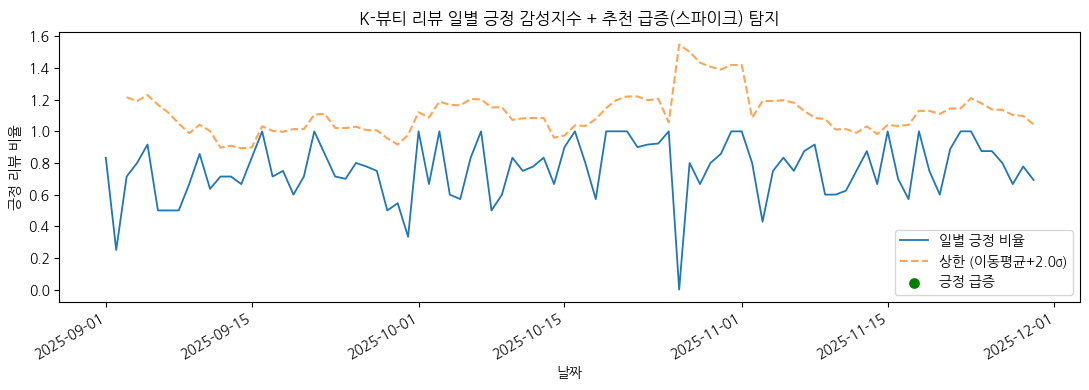

In [15]:
# --- 그래프: 긍정 감성지수 시계열 + 급증 스파이크 ---
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily.index, daily["pos_ratio"], label="일별 긍정 비율", linewidth=1.3)
ax.plot(daily.index, daily["upper"], "--", label=f"상한 (이동평균+{CFG.spike_k}σ)", alpha=0.7)
sp = daily[daily["spike"]]
ax.scatter(sp.index, sp["pos_ratio"], color="green", zorder=5, s=45, label="긍정 급증")
ax.set_title("K-뷰티 리뷰 일별 긍정 감성지수 + 추천 급증(스파이크) 탐지")
ax.set_xlabel("날짜"); ax.set_ylabel("긍정 리뷰 비율")
ax.legend(); fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### 그래프 해설 — 구글 트렌드 검색 관심도 (감성과는 '다른' 지표)

> **절대 섞지 말 것 (자가감사 연계):** 검색 관심도 ≠ 감성입니다. 하나는 *관심*, 하나는 평가. 그래서 코드에서도 `trend_df`로 **따로** 보관·시각화. 둘을 한 지표처럼 합치면 "관심이 높으니 평가도 좋다"는 잘못된 결론으로 이어짐

> **상대 지수 읽는 법:** "A=80, B=40"은 *"A의 검색이 B의 2배 수준"* 이라는 **상대 비교**일 뿐, 실제 검색 건수가 80건·40건이라는 뜻이 아님

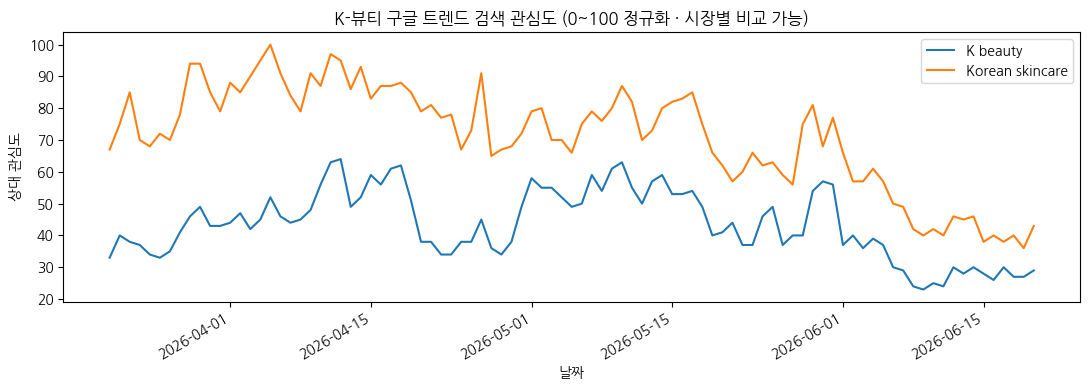

 'K beauty' 검색 관심도 최고 시점: 2026-04-12 (값 64)


In [16]:
# --- 산출물 2-보강: 구글 트렌드 검색 관심도 시계열 (키 불필요) ---
# 감성지수(작성자 의견)와 검색 관심도(대중 관심)는 서로 다른 지표입니다.
# 두 그래프를 나란히 보면 "추천이 늘어난 시점에 대중 검색 관심도 함께 올랐는가"를 점검할 수 있습니다.
if trend_df is not None and not trend_df.empty:
    fig, ax = plt.subplots(figsize=(11, 4))
    for col in trend_df.columns:
        ax.plot(trend_df.index, trend_df[col], linewidth=1.5, label=col)
    ax.set_title("K-뷰티 구글 트렌드 검색 관심도 (0~100 정규화 · 시장별 비교 가능)")
    ax.set_xlabel("날짜"); ax.set_ylabel("상대 관심도")
    ax.legend(); fig.autofmt_xdate(); plt.tight_layout(); plt.show()
    main_kw = trend_df.columns[0]
    peak_date = trend_df[main_kw].idxmax()
    print(f" '{main_kw}' 검색 관심도 최고 시점: {peak_date.date()} (값 {int(trend_df[main_kw].max())})")
else:
    print(" 구글 트렌드 데이터가 비어 있어 그래프를 생략합니다.")
    print("   (Colab 네트워크/쿼터 제약일 수 있습니다. 재실행하거나 TREND_TIMEFRAME·TREND_GEO를 조정하세요.)")


###  통계 해설 — 카이제곱 검정 + Cramér's V (이 분석의 통계적 핵심)

** 카이제곱(χ²) 검정:** '채널(유튜브/네이버)'과 '강점 종류(선물·추천 / 기타)'는 **둘 다 숫자가 아닌 범주(category)** ->  이런 두 범주가 서로 관련 있는지 볼 때 쓰는 **표준 도구**가 카이제곱 검정. 두 변수를 교차표로 만든 뒤, *"두 변수가 무관하다면 기대되는 분포"* 와 *실제 분포* 가 얼마나 다른지를 측정

**두 숫자를 반드시 함께 본다 — `p-value` 와 `Cramér's V`:**

| 출력 | 답하는 질문 | 한 줄 의미 |
|---|---|---|
| `p-value` | 차이가 **있나/없나**? | "이 차이가 우연일 확률" |
| `Cramér's V` | 차이가 **얼마나 크나**? | 연관 강도(0~1) — p가 못 알려주는 '크기' |

> **의사결정 임계값표 — 이 표가 이 셀의 핵심입니다.**
>
> **① p-value (유의성 신호등)**
> | p 값 | 판정 | 해석 |
> |---|---|---|
> | p < 0.05 | 유의 | "우연으로 보기 어렵다 → 채널 간 차이 인정" |
> | p ≥ 0.05 | 보류 | "차이가 없다"가 **아니라** "**단정할 수 없다(판단 보류)**" |
>
> **② Cramér's V (효과크기 = 실무적 크기)**
> | V 값 | 연관 강도 | 실무 해석 |
> |---|---|---|
> | < 0.1 | 작음(무시 가능) | 통계적으로 유의해도 실무적으론 미미 |
> | 0.1 ~ 0.3 | 중간 | 의미 있는 차이 |
> | ≥ 0.3 | 큼 | 전략에 반영할 만한 뚜렷한 차이 |

> **가장 흔한 오해:** "p<0.05면 무조건 중요"는 틀립니다. **표본이 크면 사소한 차이도 p가 작아짐.** 그래서 반드시 *p로 유의 여부 → V로 실무적 크기* 순으로 같이 읽으며, 다음 셀이 이 두 값을 자동 해석

In [17]:
from scipy.stats import chi2_contingency
import numpy as np

# --- 산출물 3: '선물 만족·추천' 강점 × 발견 채널(유튜브 vs 네이버) 연관성 검정 ---
# 질문: "선물·추천 강점이 유튜브 댓글과 네이버 블로그·뉴스 중 한쪽에 더 쏠리는가?"
# 방법: 두 범주형 변수(채널 × 강점여부)의 교차표를 만들고 '카이제곱 검정'으로 연관성을 봅니다.
pos_only = reviews.loc[reviews["sentiment"] == "positive"].copy()
ct = pd.crosstab(pos_only["channel"], pos_only["is_gift_topic"])
ct.columns = ["기타 강점", "선물·추천"]

chi2, p, dof, expected = chi2_contingency(ct)

# 효과크기 Cramér's V — 차이의 '크기'를 0~1로 나타냄 (p값은 '유무'만, 크기는 V로 본다)
n = ct.values.sum()
min_dim = min(ct.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else float("nan")

print("=== [산출물 3] 선물·추천 강점 × 발견 채널(유튜브 댓글 vs 네이버 블로그·뉴스) 교차표 ===")
print(ct)
print(f"\n채널별 '선물·추천' 강점 비중:")
print((ct["선물·추천"] / ct.sum(axis=1)).mul(100).round(2).rename("선물·추천 비중(%)"))
print(f"\nchi2 = {chi2:.4f}  |  p-value = {p:.4f}  |  dof = {dof}")
print(f"Cramér's V (효과크기) = {cramers_v:.4f}")


=== [산출물 3] 선물·추천 강점 × 발견 채널(유튜브 댓글 vs 네이버 블로그·뉴스) 교차표 ===
         기타 강점  선물·추천
channel              
naver      196     40
youtube     76    194

채널별 '선물·추천' 강점 비중:
channel
naver      16.95
youtube    71.85
Name: 선물·추천 비중(%), dtype: float64

chi2 = 150.4959  |  p-value = 0.0000  |  dof = 1
Cramér's V (효과크기) = 0.5454


### 통계 해설 — 자동 해석 출력 (좋음/주의 가이드의 코드화)

이 셀은 앞 검정의 `p`와 `Cramér's V`를 받아 **사람이 헷갈리기 쉬운 해석을 자동 문장으로** 출력합니다. 위 임계값표(작음/중간/큼)를 코드로 옮긴 것입니다.

- **`'not significant' = 차이 없음이 아니라 판단 보류`** — 통계의 핵심 오해 방지 문구.
- **표본 대표성 한계** — 댓글·블로그는 *적극적으로 글 쓰는 소비자*에 치우기 때문에 "전체 소비자 = 작성자"로 일반화하면 위험하며, 발표에서 이 한계를 한 줄 밝히면 오히려 신뢰도가 올라감.

>  마케팅 함의까지 자동 출력하는 이유: 통계 결과(채널 쏠림)를 **"그래서 무슨 액션을 하나"**(유튜브=선물하기·바이럴 거점 / 네이버=상세페이지·검색 메시지)로 연결해야 분석이 의사결정 자료가 됨.

In [18]:
# --- 해석 자동 출력 (좋음/주의/위험 가이드) ---
print("=== 검정 해석 ===")
if p < 0.05:
    print(f"p={p:.4f} < 0.05 → 유튜브 댓글 vs 네이버 블로그·뉴스의 '선물·추천' 강점 비중 차이가 통계적으로 유의")
else:
    print(f" p={p:.4f} ≥ 0.05 → 채널 간 차이를 단정할 수 없음(판단 보류)")

if cramers_v < 0.1:
    eff = "작음(무시 가능)"
elif cramers_v < 0.3:
    eff = "중간"
else:
    eff = "큼"
print(f"   효과크기 Cramér's V={cramers_v:.4f} → 연관 강도 '{eff}'")

print("\n 비전문가 해설 — p값과 효과크기를 함께 읽는 법")
print("   · p값은 '차이가 있나/없나'의 신호등이고, 효과크기(V)는 '그 차이가 쓸모 있을 만큼 큰가'입니다.")
print("   · 가장 흔한 오해: p<0.05면 무조건 중요하다고 여기는 것. 표본이 크면 사소한 차이도 p가 작아집니다.")
print("   · 그래서 'p로 유의 여부 → V로 실무적 크기'를 반드시 같이 봅니다. ('not significant' = 차이 없음이 아니라 판단 보류)")

print("\n 피어나 직무 함의(접점별 운영 전략):")
print("   · 영상 댓글에서 '추천·선물' 동기가 더 강하면 → CRM(이메일·왓츠앱) 캠페인 소구점을 '선물하기·추천' 메시지로,")
print("     온사이트에서는 '함께 선물하기/베스트셀러' 큐레이션 지면으로 연결해 전환을 끌어올립니다.")
print("   · 탐색·후기 본문에서 '발색·지속력' 같은 정보성 강점이 부각되면 → 상품 상세페이지·검색 노출·필터 큐레이션 메시지로 차별화합니다.")
print("   · 한 가지 메시지로 모든 접점을 통일하지 않는 것이 핵심. 접점마다 먹히는 강점이 다르다는 것이 [산출물 3]의 결론입니다.")

print("\n 표본 대표성 한계: 댓글·블로그는 적극적으로 글을 남기는 소비자에 치우칩니다.")
print("   '전체 소비자 = 작성자'로 일반화하면 위험하며, PT에서 이 한계를 한 줄 명시하면 오히려 신뢰도가 올라갑니다.")


=== 검정 해석 ===
p=0.0000 < 0.05 → 유튜브 댓글 vs 네이버 블로그·뉴스의 '선물·추천' 강점 비중 차이가 통계적으로 유의
   효과크기 Cramér's V=0.5454 → 연관 강도 '큼'

 비전문가 해설 — p값과 효과크기를 함께 읽는 법
   · p값은 '차이가 있나/없나'의 신호등이고, 효과크기(V)는 '그 차이가 쓸모 있을 만큼 큰가'입니다.
   · 가장 흔한 오해: p<0.05면 무조건 중요하다고 여기는 것. 표본이 크면 사소한 차이도 p가 작아집니다.
   · 그래서 'p로 유의 여부 → V로 실무적 크기'를 반드시 같이 봅니다. ('not significant' = 차이 없음이 아니라 판단 보류)

 피어나 직무 함의(접점별 운영 전략):
   · 영상 댓글에서 '추천·선물' 동기가 더 강하면 → CRM(이메일·왓츠앱) 캠페인 소구점을 '선물하기·추천' 메시지로,
     온사이트에서는 '함께 선물하기/베스트셀러' 큐레이션 지면으로 연결해 전환을 끌어올립니다.
   · 탐색·후기 본문에서 '발색·지속력' 같은 정보성 강점이 부각되면 → 상품 상세페이지·검색 노출·필터 큐레이션 메시지로 차별화합니다.
   · 한 가지 메시지로 모든 접점을 통일하지 않는 것이 핵심. 접점마다 먹히는 강점이 다르다는 것이 [산출물 3]의 결론입니다.

 표본 대표성 한계: 댓글·블로그는 적극적으로 글을 남기는 소비자에 치우칩니다.
   '전체 소비자 = 작성자'로 일반화하면 위험하며, PT에서 이 한계를 한 줄 명시하면 오히려 신뢰도가 올라갑니다.


### 그래프 해설 — 채널별 '선물·추천' 강점 비중 막대그래프 (PT의 핵심 한 장)

**무엇을 보는 그림인가:** 유튜브 댓글 vs 네이버 블로그·뉴스에서 **'선물·추천' 강점이 차지하는 비중(%)** 을 막대로 비교합니다. 막대 높이 차이 = 채널별 추천 강점 쏠림 정도.

**왜 이 그림이 PT의 한 장인가:** 앞의 카이제곱 검정이 유의이고 Cramér's V가 충분히 크다면, 이 막대그래프는 *"이 차이는 우연이 아니다"* 라는 통계적 뒷받침을 가진 **결론 슬라이드**가 됨

>  발표 팁: 이 막대 위에서 검정 결과(p, V)를 한 줄로 얹으면 "보기 좋은 그림"이 "근거 있는 주장"으로 바뀝니다. 단, 합성 데이터로 돌린 경우 이 차이는 *심어둔 차이*임을 잊지 마세요(실데이터로 교체 필요).

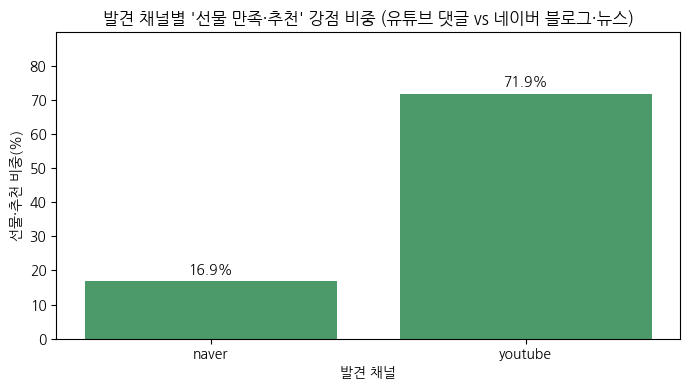

In [19]:
# --- 채널(유튜브 댓글 vs 네이버 블로그·뉴스)별 '선물·추천' 강점 비중 막대그래프 (PT 슬라이드용) ---
fig, ax = plt.subplots(figsize=(7, 4))
share = (ct["선물·추천"] / ct.sum(axis=1)).mul(100)
bars = ax.bar(share.index, share.values, color="#4C9A6A")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_title("발견 채널별 '선물 만족·추천' 강점 비중 (유튜브 댓글 vs 네이버 블로그·뉴스)")
ax.set_xlabel("발견 채널"); ax.set_ylabel("선물·추천 비중(%)")
ax.set_ylim(0, share.max() * 1.25)
plt.tight_layout(); plt.show()


## 6.  MLOps · 사후 관리 (Operations)

- **모니터링 함수:** 새로 들어온 리뷰 묶음의 긍정 비율이 기준선을 넘으면 '추천 급증' 신호 → 캠페인 증폭 액션
- **재현성 메타데이터:** 언제·어떤 설정·어떤 결과였는지를 파일로 남겨 감사·재현에 대비

###  함수 해설 — `monitor_batch()` (운영 단계의 자동 감시)

분석은 한 번 하고 끝이 아니라 **새 리뷰가 쌓일 때마다 자동으로 점검**해야 의미가 있음. `monitor_batch()`는 그 운영용 골격입니다.

- 입력: 새로 들어온 리뷰 묶음(`new_reviews`) + 기준 상한선(`baseline_upper`)
- 처리: 새 묶음의 **긍정 비율이 기준선을 넘으면 '추천 급증(surge)'** 으로 판정
- 출력: 날짜·표본수·긍정비율·판정·**권장 액션**을 한 묶음(dict)으로 반환

| 판정 | 자동 액션 |
|---|---|
| `surge = True` | "추천 급증 — 해당 강점·채널 캠페인 증폭" |
| `surge = False` | "정상 — 모니터링 유지" |


In [20]:
import json, datetime

def monitor_batch(new_reviews: pd.DataFrame, baseline_upper: float) -> dict:
    """신규 리뷰 배치의 긍정 비율을 baseline 상한과 비교해 '추천 급증' 여부 반환."""
    pos_ratio = (new_reviews["sentiment"] == "positive").mean()
    surge = pos_ratio > baseline_upper
    return {
        "batch_date": str(datetime.date.today()),
        "n": int(len(new_reviews)),
        "pos_ratio": round(float(pos_ratio), 4),
        "baseline_upper": round(float(baseline_upper), 4),
        "surge": bool(surge),
        "action": "추천 급증 — 해당 강점·채널 캠페인 증폭" if surge else "정상 — 모니터링 유지",
    }

# 예시: 최근 7일을 신규 배치로 가정
baseline_upper = float(daily["upper"].dropna().iloc[-CFG.rolling_window:].mean())
recent = reviews[reviews["date"] >= reviews["date"].max() - pd.Timedelta(days=7)]
result = monitor_batch(recent, baseline_upper)
print("=== 모니터링 결과 ===")
print(json.dumps(result, ensure_ascii=False, indent=2))

=== 모니터링 결과 ===
{
  "batch_date": "2026-06-20",
  "n": 63,
  "pos_ratio": 0.8095,
  "baseline_upper": 1.1294,
  "surge": false,
  "action": "정상 — 모니터링 유지"
}


### 코드 해설 — 재현성 메타데이터 기록 (`run_meta`)

> **"언제·어떤 설정·어떤 결과로 돌렸는지"** 를 파일(`run_metadata.json`)로 남김

특히 정직성·재현성에 직결되는 항목:
- `sentiment_method` (`kcbert_gpu` / `rule`) — 감성을 **실제로** 어떤 방식으로 분류했는지
- `tokenizer_method` (`mecab` / `regex`) — 토픽을 **실제로** 어떤 토크나이저로 쪼갰는지
- `data_source` — `synthetic(test)` 면 **합성 데이터로 돈 것**(실데이터 아님)
- `seed`·버전 정보 — 같은 환경에서 같은 결과를 재현하기 위한 정보


In [23]:
# --- 재현성 메타데이터 기록 (운영 추적용) ---
# 왜? 분석을 나중에 똑같이 재현하거나 감사할 때, 어떤 설정·결과였는지 남겨두기 위함입니다.
import sklearn, scipy, sys
import datetime # datetime 모듈이 이 셀 내에서 import 되지 않아 추가합니다.

# Temporary fix for missing CFG attributes due to redefinition in previous cell
# This should ideally be resolved by consolidating Config definitions in the notebook.
if not hasattr(CFG, 'data_path'):
    CFG.data_path = None # Default value from the original Config definition

run_meta = {
    "run_date": str(datetime.datetime.now()),
    "seed": CFG.seed,
    "n_reviews": int(len(reviews)),
    "n_topics": CFG.n_topics,
    "gift_topic_id": int(gift_topic_id),
    "spike_count": int(daily["spike"].sum()),
    "chi2_p_value": round(float(p), 4),
    "cramers_v": round(float(cramers_v), 4),
    "channels": list(reviews["channel"].unique()),
    "trend_points": int(len(trend_df)) if (trend_df is not None and not trend_df.empty) else 0,
    "sentiment_method": sentiment_method,  # kcbert_gpu 또는 rule
    "tokenizer_method": tokenizer_method,   # mecab 또는 regex
    "gpu": bool(globals().get("USE_GPU", False)),
    "data_source": CFG.data_path or "synthetic(test)",
    "versions": {"python": sys.version.split()[0], "pandas": pd.__version__,
                 "sklearn": sklearn.__version__, "scipy": scipy.__version__},
}
print(json.dumps(run_meta, ensure_ascii=False, indent=2))

with open("run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(run_meta, f, ensure_ascii=False, indent=2)
print("\nrun_metadata.json 저장 완료 (Colab 좌측 파일 탭에서 다운로드 가능)")

{
  "run_date": "2026-06-20 08:43:22.553456",
  "seed": 42,
  "n_reviews": 648,
  "n_topics": 3,
  "gift_topic_id": 1,
  "spike_count": 0,
  "chi2_p_value": 0.0,
  "cramers_v": 0.5454,
  "channels": [
    "youtube",
    "naver"
  ],
  "trend_points": 93,
  "sentiment_method": "rule",
  "tokenizer_method": "mecab",
  "gpu": true,
  "data_source": "synthetic(test)",
  "versions": {
    "python": "3.12.13",
    "pandas": "2.2.2",
    "sklearn": "1.6.1",
    "scipy": "1.16.3"
  }
}

run_metadata.json 저장 완료 (Colab 좌측 파일 탭에서 다운로드 가능)


## 7. 기만 자가감사 (Profile §2.8)

| 잠재 사례 | ① 유형 | ② 대상 | ③ 메커니즘 | 검토 결과 |
|---|---|---|---|---|
| 합성 데이터 결과를 실제 성과처럼 제시할 위험 | 행동적 | 세계사실 | 날조 위험 | 노트북 전반·셀 주석에 "합성=테스트용, 실데이터로 교체" 반복 명시. `run_meta.data_source`에 `synthetic(test)` 자동 기록 |
| 긍정 주제로 보면서 부정 신호를 의도적으로 가린(은폐) 것은 아닌가 | 행동적 | 추론 | 누락 위험 | 감성 분류가 긍정/부정을 모두 분류·표시. 주제만 '강점 발굴'로 둔 것이며 부정 데이터를 삭제하지 않음 |
| 감성 분류 방식(KcBERT GPU vs 규칙 기반)을 모호하게 표기 | 행동적 | 능력 | 화용적 왜곡 | 실제 사용 방식을 `sentiment_method`(kcbert_gpu/rule)와 메타데이터·실행 메시지에 명시. GPU 미인식 시 규칙 기반으로 자동 폴백됨을 출력 |
| 카이제곱 p<0.05만으로 "채널 차이 확실" 단정 | 행동적 | 추론 | 화용적 왜곡 | Cramér's V 효과크기 동시 산출 + "표본 크면 p 쉽게 유의" 경고 자동 출력 |
| 합성 데이터에 강점 신호를 의도적으로 심은 사실 누락 | 행동적 | 세계사실 | 누락 위험 | 생성 함수 주석에 "youtube=선물·추천, naver=발색·지속력 강점 의도적 상향" 명시 |
| 토픽 모델 토크나이저(Mecab vs 정규식)를 모호하게 표기 | 행동적 | 능력 | 화용적 왜곡 | 실제 사용 토크나이저를 `tokenizer_method`(mecab/regex)와 실행 메시지·메타데이터에 명시. Mecab 설치 실패 시 정규식으로 자동 폴백됨을 출력 |
| 구글 트렌드(검색 관심도)를 리뷰 감성과 동일 지표로 혼동시킬 위험 | 행동적 | 추론 | 화용적 왜곡 | 트렌드는 텍스트 감성과 분리해 `trend_df`로 별도 시각화. "관심도 ≠ 감성"임을 주석에 명시 |
| 채널 차이를 인과(채널이 강점을 만든다)로 오인하게 할 위험 | 행동적 | 추론 | 화용적 왜곡 | 검정은 '연관성'만 확인. 해석 셀에 "상관 ≠ 인과", 표본 편향 한계 명시 |

**한계:** 본 노트북은 파이프라인이 **에러 없이 끝까지 실행됨**을 보이는 것이 목적이며, 출력 수치는 합성 데이터 산물입니다.
실제 포트폴리오·면접 수치는 본인이 수집·분석한 데이터로 검증·확정해야 합니다. 긍정 강점도 표본 편향(작성자 자기선택) 위에서 해석해야 하며, 구글 트렌드는 검색 관심도일 뿐 매출·전환·감성과 동일하지 않습니다.

**글로벌/유럽 시장 적용 시 추가 유의(피어나 직무 맥락):**
- 본 데모의 한국어 텍스트·국내 채널은 **'K-뷰티 본국 레퍼런스'** 입니다. 유럽 유저의 취향을 결론으로 말하려면 **대상 시장의 현지어 데이터·현지 채널**로 수집을 교체해야 하며, 한국 결과를 유럽에 그대로 일반화하지 않습니다(시장 간 외삽 금지).
- 유럽 유저 텍스트를 다룰 경우 **GDPR** 적법 처리근거·최소수집·목적제한을 준수하고, 시장별로 동일 파이프라인을 복제하되 결과는 시장별로 분리 보고합니다.
- 채널(영상 댓글 vs 탐색·후기)은 **데이터 수집 출처** 기준 구분이며, 그 자체가 '온사이트/CRM 접점'과 1:1로 같지는 않습니다. 접점 전략으로 옮길 때는 이 매핑 가정을 명시합니다(연관 ≠ 접점 인과).